# 02 Train Siamese Network

This notebook trains the Siamese network using the extracted image pairs from `train_labels.csv`.

Two versions are trained and compared:
1. Without augmentation
2. With augmentation

The better model is selected based on validation loss and used later in `03_test_siamese.ipynb`.

## 1. Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
from pathlib import Path
import sys

import pandas as pd
import torch
import numpy
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from siamese_model import SiameseLossDetector
from siamese_utils import (
    set_seed,
    get_device,
    get_dl_kwargs,
    TRAIN_LABELS_CSV,
    WEIGHTS_DIR,
    SIAMESE_DIR,
)

In [25]:
set_seed(42)

device = get_device()
dl_kwargs = get_dl_kwargs()

print("Device:", device)
print("DataLoader kwargs:", dl_kwargs)

WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

Device: mps
DataLoader kwargs: {'num_workers': 0, 'pin_memory': False}


## 2. Load Training Labels

In [15]:
df = pd.read_csv(TRAIN_LABELS_CSV)

print("Total pairs:", len(df))
print(df["label"].value_counts())

df.head()

Total pairs: 16640
label
0    8960
1    7680
Name: count, dtype: int64


,img1,img2,label,source_video,frame1,frame2
0,data/extracted_pairs/pair_000000_1.jpg,data/extracted_pairs/pair_000000_2.jpg,0,videos_normal/back_box_1.mp4,605,160
1,data/extracted_pairs/pair_000001_1.jpg,data/extracted_pairs/pair_000001_2.jpg,0,videos_normal/back_box_1.mp4,1440,1285
2,data/extracted_pairs/pair_000002_1.jpg,data/extracted_pairs/pair_000002_2.jpg,0,videos_normal/back_box_1.mp4,1175,745
3,data/extracted_pairs/pair_000003_1.jpg,data/extracted_pairs/pair_000003_2.jpg,0,videos_normal/back_box_1.mp4,555,2825
4,data/extracted_pairs/pair_000004_1.jpg,data/extracted_pairs/pair_000004_2.jpg,0,videos_normal/back_box_1.mp4,480,3055


## 3. Train / Validation Split

Split the extracted pairs into training and validation sets using an 80/20 split while keeping both classes represented.

In [16]:
train_parts = []
val_parts = []

for label, group in df.groupby("label"):
    group = group.sample(frac=1, random_state=42).reset_index(drop=True)
    split_idx = int(0.8 * len(group))

    train_parts.append(group.iloc[:split_idx])
    val_parts.append(group.iloc[split_idx:])

train_df = pd.concat(train_parts).sample(frac=1, random_state=42).reset_index(drop=True)
val_df = pd.concat(val_parts).sample(frac=1, random_state=42).reset_index(drop=True)

print("Train:", len(train_df))
print(train_df["label"].value_counts())

print("Val:", len(val_df))
print(val_df["label"].value_counts())

Train: 13312
label
0    7168
1    6144
Name: count, dtype: int64
Val: 3328
label
0    1792
1    1536
Name: count, dtype: int64


## 4. Dataset Class

This dataset supports optional augmentation. When augmentation is enabled, it is applied only to the second image in the pair. This helps the model learn that lighting or camera variation alone should not imply payload loss.

In [17]:
class SiamesePairDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment

        self.base_transform = transforms.Compose([
            transforms.Resize((120, 160)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

        self.augment_transform = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.02,
            ),
            transforms.GaussianBlur(kernel_size=3),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img1_path = SIAMESE_DIR / row["img1"]
        img2_path = SIAMESE_DIR / row["img2"]

        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        if self.augment:
            img2 = self.augment_transform(img2)

        img1 = self.base_transform(img1)
        img2 = self.base_transform(img2)

        label = torch.tensor([float(row["label"])], dtype=torch.float32)

        return img1, img2, label

## 5. Training Function

The model is trained using weighted binary cross-entropy to reduce the effect of class imbalance.

Early stopping is applied with a patience of 15 epochs.

In [18]:
def train_one_model(run_name, use_augmentation, num_epochs=100, patience=15, batch_size=32, lr=1e-3):
    print(f"\nTraining run: {run_name}")
    print("Augmentation:", use_augmentation)

    train_dataset = SiamesePairDataset(train_df, augment=use_augmentation)
    val_dataset = SiamesePairDataset(val_df, augment=False)

    # Dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        **dl_kwargs,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        **dl_kwargs,
    )

    model = SiameseLossDetector().to(device)

    pos_count = (train_df["label"] == 1).sum()
    neg_count = (train_df["label"] == 0).sum()
    pos_weight = neg_count / pos_count

    print("Positive weight:", pos_weight)

    criterion = nn.BCELoss(reduction="none")
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
    )

    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    weights_path = WEIGHTS_DIR / f"{run_name}.pth"
    history = []

    for epoch in range(1, num_epochs + 1):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for img1, img2, labels in tqdm(train_loader, desc=f"{run_name} Epoch {epoch} Train", leave=False):
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(img1, img2)

            sample_weights = torch.where(
                labels == 1,
                torch.tensor(pos_weight, device=device, dtype=torch.float32),
                torch.tensor(1.0, device=device, dtype=torch.float32),
            )

            loss = criterion(outputs, labels)
            loss = (loss * sample_weights).mean()

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * labels.size(0)

            preds = (outputs >= 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for img1, img2, labels in tqdm(val_loader, desc=f"{run_name} Epoch {epoch} Val", leave=False):
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.to(device)

                outputs = model(img1, img2)

                sample_weights = torch.where(
                    labels == 1,
                    torch.tensor(pos_weight, device=device, dtype=torch.float32),
                    torch.tensor(1.0, device=device, dtype=torch.float32),
                )

                loss = criterion(outputs, labels)
                loss = (loss * sample_weights).mean()

                val_loss += loss.item() * labels.size(0)

                preds = (outputs >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history.append({
            "run_name": run_name,
            "augmentation": use_augmentation,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            torch.save(model.state_dict(), weights_path)
            print(f"Saved best model to {weights_path}")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    return pd.DataFrame(history), weights_path, best_val_loss, best_epoch

## 6. Train Without Augmentation

In [19]:
history_no_aug, weights_no_aug, best_loss_no_aug, best_epoch_no_aug = train_one_model(
    run_name="siamese_no_aug",
    use_augmentation=False,
    num_epochs=100,
    patience=15,
    batch_size=32,
    lr=1e-3,
)


Training run: siamese_no_aug
Augmentation: False
Positive weight: 1.1666666666666667


siamese_no_aug Epoch 1 Train:   0%|          | 0/416 [00:00<?, ?it/s]

siamese_no_aug Epoch 1 Val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 0.4339 | Train Acc: 0.8080 | Val Loss: 0.3103 | Val Acc: 0.8558
Saved best model to /Users/tohjiale/Desktop/payload_loss_detection/weights/siamese_no_aug.pth


siamese_no_aug Epoch 2 Train:   0%|          | 0/416 [00:00<?, ?it/s]

...

siamese_no_aug Epoch 58 Val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 058 | Train Loss: 0.0409 | Train Acc: 0.9851 | Val Loss: 0.0984 | Val Acc: 0.9751


siamese_no_aug Epoch 59 Train:   0%|          | 0/416 [00:00<?, ?it/s]

siamese_no_aug Epoch 59 Val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 059 | Train Loss: 0.0452 | Train Acc: 0.9838 | Val Loss: 0.1039 | Val Acc: 0.9724
Early stopping at epoch 59. Best epoch: 44


## 7. Train With Augmentation

In [20]:
history_aug, weights_aug, best_loss_aug, best_epoch_aug = train_one_model(
    run_name="siamese_aug",
    use_augmentation=True,
    num_epochs=100,
    patience=15,
    batch_size=32,
    lr=1e-3,
)


Training run: siamese_aug
Augmentation: True
Positive weight: 1.1666666666666667


siamese_aug Epoch 1 Train:   0%|          | 0/416 [00:00<?, ?it/s]

siamese_aug Epoch 1 Val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 0.4884 | Train Acc: 0.7786 | Val Loss: 0.3737 | Val Acc: 0.8368
Saved best model to /Users/tohjiale/Desktop/payload_loss_detection/weights/siamese_aug.pth


siamese_aug Epoch 2 Train:   0%|          | 0/416 [00:00<?, ?it/s]

...

siamese_aug Epoch 50 Val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 050 | Train Loss: 0.0829 | Train Acc: 0.9709 | Val Loss: 0.1227 | Val Acc: 0.9519


siamese_aug Epoch 51 Train:   0%|          | 0/416 [00:00<?, ?it/s]

siamese_aug Epoch 51 Val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 051 | Train Loss: 0.0876 | Train Acc: 0.9690 | Val Loss: 0.1312 | Val Acc: 0.9519
Early stopping at epoch 51. Best epoch: 36


## 8. Compare Training Runs

The model with the lower best validation loss is selected for later evaluation.

In [21]:
history_df = pd.concat([history_no_aug, history_aug], ignore_index=True)

summary_df = pd.DataFrame([
    {
        "run_name": "siamese_no_aug",
        "augmentation": False,
        "best_epoch": best_epoch_no_aug,
        "best_val_loss": best_loss_no_aug,
        "weights_path": weights_no_aug,
    },
    {
        "run_name": "siamese_aug",
        "augmentation": True,
        "best_epoch": best_epoch_aug,
        "best_val_loss": best_loss_aug,
        "weights_path": weights_aug,
    },
])

summary_df

,run_name,augmentation,best_epoch,best_val_loss,weights_path
0,siamese_no_aug,False,44,0.068764,/Users/tohjiale/Desktop/payload_loss_detection...
1,siamese_aug,True,36,0.113096,/Users/tohjiale/Desktop/payload_loss_detection...


In [22]:
if best_loss_aug < best_loss_no_aug:
    best_run = "siamese_aug"
    best_weights = weights_aug
else:
    best_run = "siamese_no_aug"
    best_weights = weights_no_aug

print("Best run:", best_run)
print("Use this weights file in 03_test_siamese:", best_weights)

Best run: siamese_no_aug
Use this weights file in 03_test_siamese: /Users/tohjiale/Desktop/payload_loss_detection/weights/siamese_no_aug.pth


## 9. Plot Loss Curves

The standard and log-scaled loss curves are shown side by side. The dashed vertical line marks the epoch where the best model was saved based on validation loss.

In [34]:
def plot_loss_curves(history_df, run_name):
    run_history = history_df[history_df["run_name"] == run_name].copy()

    epochs = run_history["epoch"].values
    train_loss = run_history["train_loss"].values
    val_loss = run_history["val_loss"].values

    best_epoch = run_history.loc[run_history["val_loss"].idxmin(), "epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Normal loss curve
    axes[0].plot(epochs, train_loss, label="Train Loss", linewidth=2)
    axes[0].plot(epochs, val_loss, label="Validation Loss", linewidth=2)
    axes[0].axvline(
        x=best_epoch,
        linestyle="--",
        alpha=0.7,
        label=f"Best Model (Epoch {best_epoch})",
    )
    axes[0].set_title(f"Loss Curve - {run_name}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # Log loss curve
    axes[1].plot(epochs, train_loss, label="Train Loss", linewidth=2)
    axes[1].plot(epochs, val_loss, label="Validation Loss", linewidth=2)
    axes[1].axvline(
        x=best_epoch,
        linestyle="--",
        alpha=0.7,
        label=f"Best Model (Epoch {best_epoch})",
    )
    axes[1].set_yscale("log")
    axes[1].set_title(f"Log Loss Curve - {run_name}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss (log scale)")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    # plt.savefig("fig11_siamese_loss_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

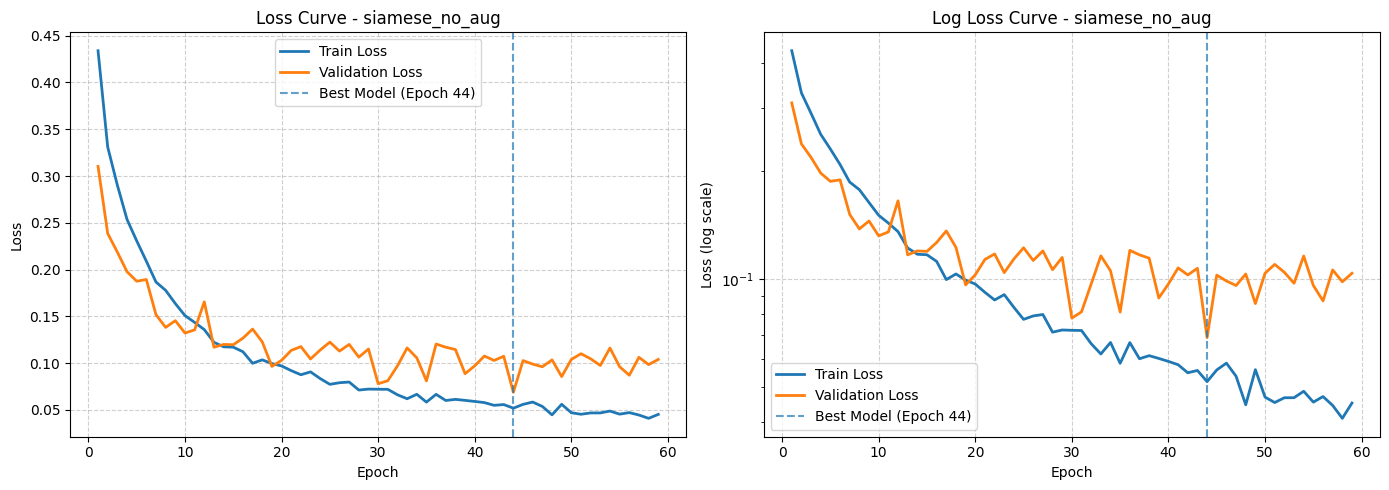

In [35]:
plot_loss_curves(history_df, "siamese_no_aug")

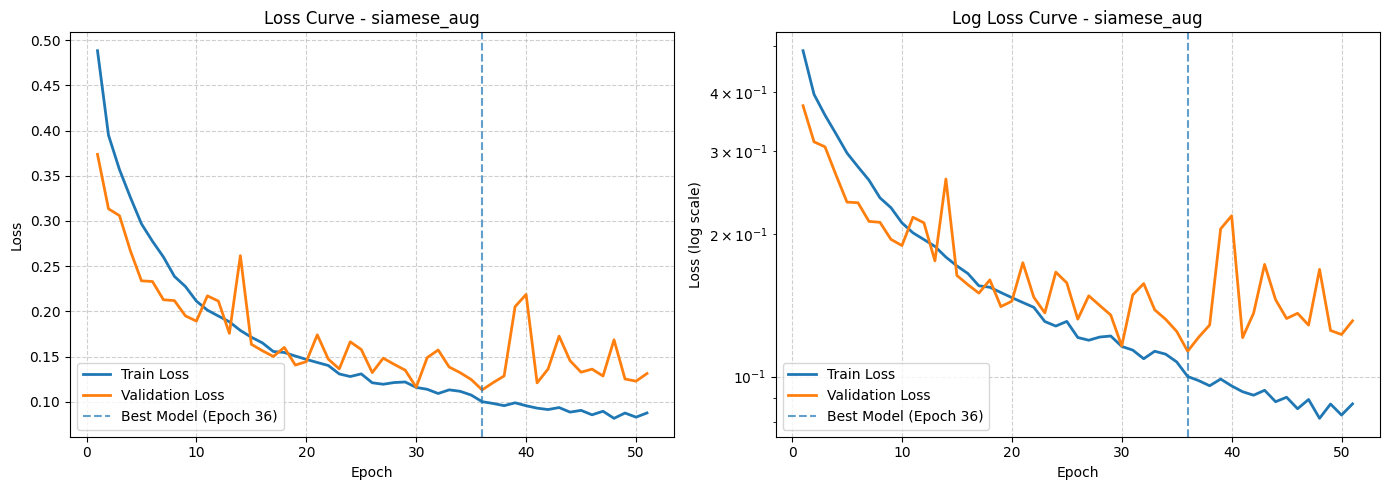

In [28]:
plot_loss_curves(history_df, "siamese_aug")

## 10. Plot Accuracy Curves

The accuracy curves compare training and validation accuracy for both runs.

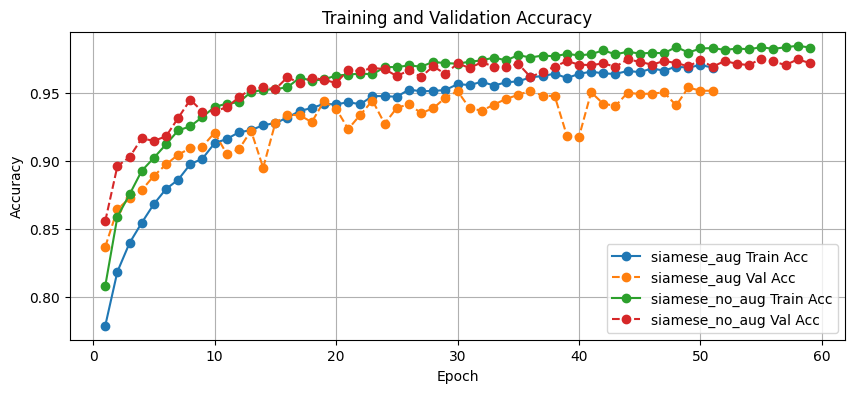

In [37]:
plt.figure(figsize=(10, 4))

for run_name, group in history_df.groupby("run_name"):
    plt.plot(group["epoch"], group["train_acc"], marker="o", label=f"{run_name} Train Acc")
    plt.plot(group["epoch"], group["val_acc"], marker="o", linestyle="--", label=f"{run_name} Val Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
# plt.savefig("fig12_siamese_acc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Conclusion

The Siamese network trained without data augmentation outperformed the augmented variant, achieving a lower best validation loss of 0.0688 compared to 0.1131. This suggests that the model is able to generalize well to the target environment without requiring additional variability from augmentation. In this case, augmentation may have introduced unnecessary variation that did not reflect real deployment conditions, leading to slightly degraded performance. Therefore, the non-augmented model was selected for final evaluation.

`siamese_no_aug.pth` has been renamed to `siamese_best.pth` for evaluation in `03_test_siamese.ipynb`.